## Greedy Heuristic: Assign Jobs To Machines

Given a list of processing times for jobs, assign those jobs to machines to minimize the makespan (i.e. the longest total processing time among all machines).

High-level description:
- Process jobs in order of their processing times from large to small. When two jobs have the same processing time, process the one with the smaller job ID first.
- Then, for each job, assign that job to the machine with currently the smallest total processing time.

Problem 4-5 of week 3 quiz for [Operations Research (2): Optimization Algorithms](https://www.coursera.org/learn/operations-research-algorithms/home/welcome).

In [2]:
# Imports and helper function
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import LinearConstraint, milp, Bounds

def plot_timeline(processing_times, machine, ax):
    series = processing_times[processing_times != 0].cumsum()
    for idx, row in pd.concat([series.rename("end"), series.shift(1, fill_value=0).rename("start")], axis=1).iterrows():
        ax.barh(
            y=str(machine),
            width=row["end"] - row["start"],
            left=row["start"],
            height=0.8,
            color="skyblue",
            edgecolor="black"
        )
        text = str(idx)
        # text = str(row["end"] - row["start"])
        plt.text(row["start"] + 0.5, machine - 0.2, text)

    plt.xticks([0, 10, 20, 30, 40, 43])
    plt.xlabel("Time")

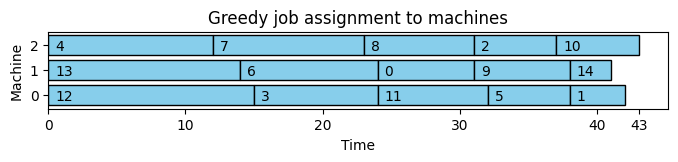

Makespan (longest total processing time): 43
Upper bound - linear relaxation: 42.0
Optimality gap: 2.38%


In [3]:
# Greedy heuristic

# Input data
processing_times = np.array([7, 4, 6, 9, 12, 6, 10, 11, 8, 7, 6, 8, 15, 14, 3])

# Convert processing times to list of (job ID, processing time)
arr = list(enumerate(processing_times))

# Sort by processing time (descending) then job ID (ascending)
arr.sort(key=lambda t: (-t[1], t[0]))

machines = 3
machine_jobs = [[] for _ in range(machines)]
machine_processing_times = [0] * machines
for job in arr:
    idx = machine_processing_times.index(min(machine_processing_times))
    machine_jobs[idx].append(job[0])
    machine_processing_times[idx] += job[1]

fig, ax = plt.subplots(figsize=(8, 1))
plt.ylabel("Machine")
plt.title("Greedy job assignment to machines")
for machine in range(machines):
    plot_timeline(pd.Series(processing_times[machine_jobs[machine]], index=machine_jobs[machine]), machine, ax)
plt.show()

print("Makespan (longest total processing time):", max(machine_processing_times))

# Linear relaxation has perfectly even assignment, so it's just the average
lin_relax = sum(processing_times) / machines
print("Upper bound - linear relaxation:", lin_relax)
print(f"Optimality gap: {(max(machine_processing_times) - lin_relax) / lin_relax:.2%}")

## Integer Programming: Assign Jobs To Machines With Compatibility

Given a list of processing times for jobs, assign those jobs to machines to minimize the makespan (i.e. the longest total processing time among all machines).

Some jobs are incompatible with others, and cannot be performed by the same machine.

Problem 1 of final (week 6) quiz for [Operations Research (2): Optimization Algorithms](https://www.coursera.org/learn/operations-research-algorithms/home/welcome).

In [4]:
# Input data

processing_times = np.array([7, 4, 6, 9, 12, 8, 10, 11, 8, 7, 6, 8, 15, 14, 3])

incompatible_jobs = [
    [1, 4],
    [1, 7],
    [4, 7],
    [6, 9],
    [10, 14],
]

machines = 3

In [5]:
# Set objective and constraints

# Variables:
# [machine 1 job 1, machine 1 job 2, ..., machine 2 job 1, machine 2 job 2, ..., max processing time]

jobs = len(processing_times)
job_vars = jobs * machines
var_count = job_vars + 1

# Only minimise max processing time
coef = [0] * jobs * machines + [1]

constraints = []

# Avoid conflicting jobs
for machine in range(machines):
    for job1, job2 in incompatible_jobs:
        A_curr = np.zeros(var_count)
        A_curr[jobs * machine + job1] = 1
        A_curr[jobs * machine + job2] = 1
        constraints.append(LinearConstraint(A_curr, ub=1))

# Make sure each job is on exactly 1 machine
for job in range(jobs):
    A_curr = np.zeros(var_count)
    for machine in range(machines):
        A_curr[jobs * machine + job] = 1
    constraints.append(LinearConstraint(A_curr, 1, 1))

# Set max processing time to be >= processing time per machine
# We set this as: processing time per machine - max processing time <= 0
zero_times = np.full_like(processing_times, 0)
for arrs in [
    [processing_times, zero_times, zero_times, [-1]],
    [zero_times, processing_times, zero_times, [-1]],
    [zero_times, zero_times, processing_times, [-1]],
]:
    constraints.append(LinearConstraint(np.concat(arrs), ub=0))

# Make sure each job is in {0, 1}
# Max processing time is just >= 0
bounds = Bounds(np.zeros(var_count), np.append(np.ones(jobs * machines), [np.inf]))

In [6]:
# Run solver

# Set all variables to be integers
integrality = np.ones_like(coef)

res = milp(coef, integrality=integrality, bounds=bounds, constraints=constraints)
res

        message: Optimization terminated successfully. (HiGHS Status 7: Optimal)
        success: True
         status: 0
            fun: 43.0
              x: [ 1.000e+00  1.000e+00 ...  0.000e+00  4.300e+01]
 mip_node_count: 1
 mip_dual_bound: 43.0
        mip_gap: 0.0

Makespan (longest total processing time): 43.0


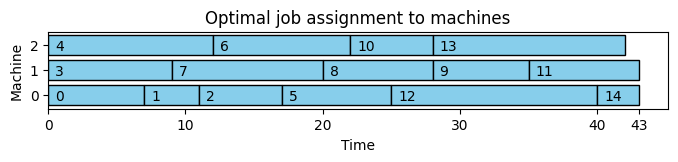

In [7]:
# Print solution details

print("Makespan (longest total processing time):", res.x[-1])

fig, ax = plt.subplots(figsize=(8, 1))
plt.ylabel("Machine")
plt.title("Optimal job assignment to machines")
for machine in range(machines):
    plot_timeline(pd.Series(processing_times * res.x[jobs * machine : jobs * (machine + 1)]), machine, ax)